In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.pipeline.features.wnba_min_features import (
    WNBA_MIN_FEATURES,
    TARGET,
    build_wnba_min_dataset,
    validate_wnba_min_dataset,
)

warnings.filterwarnings("ignore")


In [7]:
pd.set_option("display.max_columns", None)

# Pull silver.wnba_player_gamelogs by season, engineer features, cache parquet.
from src.pipeline.gold import _read_silver_slice

CACHE_PATH = Path("data/cache/wnba_min_from_silver.parquet")
FORCE_REBUILD = False  # set True after changing wnba_min_features.py or silver data

# WNBA seasons are calendar years in silver (e.g. "2025").
SEASONS = [
    ("2022", "S22"),
    ("2023", "S23"),
    ("2024", "S24"),
    ("2025", "S25"),
]
SEASON_TYPES = ("Regular Season", "Playoffs")


def load_season_from_silver(season_year: str) -> pd.DataFrame:
    parts = []
    for season_type in SEASON_TYPES:
        part = _read_silver_slice(season_year, season_type, league="wnba")
        print(f"  {season_year} {season_type}: {len(part):,} rows")
        if not part.empty:
            parts.append(part)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True).sort_values("GAME_DATE")


df = None
if CACHE_PATH.exists() and not FORCE_REBUILD:
    cached = pd.read_parquet(CACHE_PATH)
    missing = [c for c in WNBA_MIN_FEATURES if c not in cached.columns]
    if missing:
        print(
            f"  cache stale — missing {len(missing)} WNBA_MIN_FEATURES "
            f"(e.g. {missing[:3]}); rebuilding…"
        )
    else:
        df = cached
        df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
        print(f"Loaded cache {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")

if df is None:
    season_dfs = []
    season_map = {}
    for i, (season_year, label) in enumerate(SEASONS):
        part = load_season_from_silver(season_year)
        if part.empty:
            print(f"  ⚠ skip {season_year}: no silver rows")
            continue
        season_map[len(season_dfs)] = label
        season_dfs.append(part)
        print(f"  → {label}: {len(part):,} raw rows")

    if not season_dfs:
        raise RuntimeError(
            "No WNBA silver seasons loaded — run "
            'python scripts/fetch_raw.py --league wnba --season 2025 '
            'first'
        )

    print("Building WNBA MIN features (this can take a few minutes)...")
    df = build_wnba_min_dataset(season_dfs, season_map=season_map)
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values("GAME_DATE").reset_index(drop=True)

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE_PATH, index=False)
    print(f"Wrote {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")

df.sample(5)


  2022 Regular Season: 4,096 rows
  2022 Playoffs: 423 rows
  → S22: 4,519 raw rows
  2023 Regular Season: 4,544 rows
  2023 Playoffs: 354 rows
  → S23: 4,898 raw rows
  2024 Regular Season: 4,515 rows
  2024 Playoffs: 399 rows
  → S24: 4,914 raw rows
  2025 Regular Season: 5,407 rows
  2025 Playoffs: 446 rows
  → S25: 5,853 raw rows
Building WNBA MIN features (this can take a few minutes)...
Wrote data\cache\wnba_min_from_silver.parquet: 18,372 rows × 215 cols


,GAME_ID,PLAYER_ID,BUILT_AT,SEASON_YEAR,SEASON_TYPE,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,SP_WORK_OFF_RATING,E_DEF_RATING,DEF_RATING,SP_WORK_DEF_RATING,E_NET_RATING,NET_RATING,SP_WORK_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,SP_WORK_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_CITY,TEAM_TRICODE,TEAM_SLUG,FIRST_NAME,FAMILY_NAME,NAME_I,PLAYER_SLUG,START_POSITION,COMMENT,JERSEY_NUM,MINUTES,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,ASSISTS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,FIELD_GOAL_PERCENTAGE,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_TEAM_ABBREVIATION,OPP_TEAM_NAME,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,POS,AGE,IS_PLAYOFF,TEAM_SPREAD,GAME_TOTAL,STARTING,MIN_roll10,USG_PCT_roll10,MIN_10_ewm,USG_PCT_lag1,USG_PCT_lag2,AST_PCT_lag1,PIE_lag1,GAMES_PLAYED_LAST_7_DAYS,GAMES_PLAYED_LAST_14_DAYS,MIN_SUM_LAST_7_DAYS,DAYS_REST,STARTER_ROLL10_PCT,MIN_SEASON_MEAN,MIN_SEASON_STD,MIN_RATE_OF_CHANGE,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,MIN_STD_L10,MIN_P10_L10,MIN_P90_L10,CONSEC_STARTS,SEASON
13512,1022500031,1628957,2026-07-12 07:38:16.398629+00:00,2025,Regular Season,Kathryn Westbeld,Kathryn,1611661317,PHX,Phoenix Mercury,2025-05-27,PHX vs. CHI,W,26.683333,5.0,10.0,0.500,3.0,8.0,0.375,0.0,0.0,0.00,2.0,3.0,5.0,1.0,0.0,1.0,3.0,0.0,3.0,0.0,13.0,10.0,32.5,0.0,0.0,30.0,1,26:41,1.0,112.4,120.4,120.4,97.5,98.2,98.2,14.9,22.2,22.2,0.053,0.0,9.1,0.061,0.111,0.083,0.0,0.0,0.650,0.650,0.154,0.154,102.75,98.94,82.45,98.94,0.125,54.0,5.0,10.0,Phoenix,PHX,mercury,Kathryn,Westbeld,K. Westbeld,kathryn-westbeld,C,None,None,26:41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500,0.0,0.0,0.0,33.0,78.0,0.423,16.0,40.0,0.400,12.0,19.0,0.632,10.0,20.0,30.0,26.0,11.0,11.0,7.0,5.0,18.0,21.0,94.0,5.0,107.6,111.9,101.4,104.7,6.2,7.2,0.788,2.36,21.0,0.286,0.564,0.409,0.131,0.526,0.544,105.1,101.4,84.5,84.0,0.502,1611661329,None,None,33.0,71.0,0.465,6.0,21.0,0.286,17.0,20.0,0.850,11.0,31.0,42.0,25.0,19.0,6.0,5.0,7.0,21.0,18.0,89.0,-5.0,101.4,104.7,107.6,111.9,-6.2,-7.2,0.758,1.32,19.7,0.436,0.714,0.591,0.224,0.507,0.558,105.1,101.4,84.5,85.0,0.498,C,None,None,None,None,1,23.49,0.13,22.93,0.143,0.071,0.071,0.106,3,4,72.4,2.0,1.0,23.494583,3.892261,NaN,4.0,7.0,NaN,NaN,NaN,5,S25
12857,1042400203,1627668,2026-07-12 22:45:22.821634+00:00,2024,Playoffs,Breanna Stewart,Breanna,1611661313,NYL,New York Liberty,2024-10-04,NYL @ LVA,L,33.383333,7.0,17.0,0.412,2.0,4.0,0.500,3.0,4.0,0.75,0.0,6.0,6.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,19.0,-24.0,27.7,0.0,0.0,28.0,1,33:23,1.0,88.8,90.9,90.9,127.1,129.2,129.2,-38.4,-38.3,-38.3,0.083,0.0,5.0,0.000,0.200,0.090,0.0,0.0,0.471,0.506,0.257,0.255,96.11,94.18,78.48,94.18,0.100,66.0,7.0,17.0,New York,NYL,liberty,Breanna,Stewart,B. Stewart,breanna-stewart,F,None,None,33:23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.

In [8]:
# Validate engineered frame (no GAME_ID×PLAYER_ID dups, WNBA_MIN_FEATURES present)
summary = validate_wnba_min_dataset(df)
print(f"Validated WNBA MIN frame: {summary['rows']:,} rows × {summary['cols']} cols")
print(f"Features OK ({summary['features']}): all {len(WNBA_MIN_FEATURES)} present")
print("Season counts:")
print(pd.Series(summary["seasons"]).sort_index())

FEATURE_COLS = list(WNBA_MIN_FEATURES)
# Alias for later SHAP/ablation/save cells that still say MIN_FEATURES
MIN_FEATURES = FEATURE_COLS
print(df.shape)
df.sample(3)


Validated WNBA MIN frame: 18,372 rows × 215 cols
Features OK (19): all 19 present
Season counts:
S22    4176
S23    4388
S24    4450
S25    5358
dtype: int64
(18372, 215)


,GAME_ID,PLAYER_ID,BUILT_AT,SEASON_YEAR,SEASON_TYPE,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,SP_WORK_OFF_RATING,E_DEF_RATING,DEF_RATING,SP_WORK_DEF_RATING,E_NET_RATING,NET_RATING,SP_WORK_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,SP_WORK_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_CITY,TEAM_TRICODE,TEAM_SLUG,FIRST_NAME,FAMILY_NAME,NAME_I,PLAYER_SLUG,START_POSITION,COMMENT,JERSEY_NUM,MINUTES,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,ASSISTS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,FIELD_GOAL_PERCENTAGE,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_TEAM_ABBREVIATION,OPP_TEAM_NAME,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,POS,AGE,IS_PLAYOFF,TEAM_SPREAD,GAME_TOTAL,STARTING,MIN_roll10,USG_PCT_roll10,MIN_10_ewm,USG_PCT_lag1,USG_PCT_lag2,AST_PCT_lag1,PIE_lag1,GAMES_PLAYED_LAST_7_DAYS,GAMES_PLAYED_LAST_14_DAYS,MIN_SUM_LAST_7_DAYS,DAYS_REST,STARTER_ROLL10_PCT,MIN_SEASON_MEAN,MIN_SEASON_STD,MIN_RATE_OF_CHANGE,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,MIN_STD_L10,MIN_P10_L10,MIN_P90_L10,CONSEC_STARTS,SEASON
14381,1022500079,1631007,2026-07-12 07:38:16.398629+00:00,2025,Regular Season,Veronica Burton,Veronica,1611661331,GSV,Golden State Valkyries,2025-06-19,GSV vs. IND,W,31.500000,2.0,11.0,0.182,1.0,6.0,0.167,6.0,6.0,1.0,0.0,5.0,5.0,3.0,0.0,0.0,1.0,1.0,0.0,3.0,11.0,10.0,24.5,0.0,0.0,22.0,1,31:30,1.0,103.0,103.2,103.2,82.8,88.7,88.7,20.1,14.5,14.5,0.167,0.0,17.6,0.00,0.172,0.074,0.0,0.0,0.227,0.403,0.187,0.192,98.68,95.24,79.37,95.24,0.121,63.0,2.0,11.0,Golden State,GSV,valkyries,Veronica,Burton,V. Burton,veronica-burton,G,None,None,31:30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.182,0.0,0.0,0.0,30.0,70.0,0.429,9.0,31.0,0.290,19.0,27.0,0.704,8.0,24.0,32.0,18.0,7.0,10.0,5.0,3.0,18.0,22.0,88.0,11.0,108.8,110.0,92.5,97.5,16.3,12.5,0.600,2.57,16.2,0.295,0.730,0.494,0.088,0.493,0.537,98.5,95.4,79.5,80.0,0.563,1611661325,None,None,29.0,66.0,0.439,8.0,29.0,0.276,11.0,12.0,0.917,5.0,30.0,35.0,20.0,17.0,3.0,3.0,5.0,22.0,18.0,77.0,-11.0,92.5,97.5,108.8,110.0,-16.3,-12.5,0.690,1.18,18.3,0.270,0.705,0.506,0.215,0.500,0.540,98.5,95.4,79.5,79.0,0.437,G,None,None,None,None,1,30.03,0.20,28.36,0.175,0.203,0.294,-0.019,2,5,61.4,2.0,1.0,28.865909,4.915492,2.55,2.0,3.0,3.203215,26.671167,33.344667,12,S25
10057,1022400088,1629574,2026-07-10 06:59:56.458250+00:00,2024,Regular Season,Li Yueru,Li,1611661320,LAS,Los Angeles Sparks,2024-06-20,LAS @ NYL,L,16.566667,1.0,3.0,0.333,1.0,2.0,0.500,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,1.0,0.0,0.0,5.0,1.0,3.0,2.0,9.4,0.0,0.0,10.0,1,16:34,1.0,91.2,91.4,91.4,90.7,85.7,85.7,0.5,5.7,5.7,0.182,1.0,28.6,0.00,0.111,0.069,28.6,28.6,0.500,0.500,0.143,0.143,98.74,101.41,84.51,101.41,-0.022,35.0,1.0,3.0,Los Angeles,LAS,sparks,Li,Yueru,L. Yueru,li-yueru,C,None,None,16:34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0

In [9]:
# Feature list already validated via validate_wnba_min_dataset
print(f"Features ({len(FEATURE_COLS)})")
print(FEATURE_COLS)
df[FEATURE_COLS].dtypes


Features (19)
['MIN_10_ewm', 'MIN_SEASON_MEAN', 'STARTER_ROLL10_PCT', 'CONSEC_STARTS', 'MIN_RATE_OF_CHANGE', 'TEAM_MIN_RANK_L10', 'TEAM_USG_RANK_L10', 'MIN_P10_L10', 'MIN_P90_L10', 'MIN_STD_L10', 'MIN_SEASON_STD', 'USG_PCT_lag1', 'USG_PCT_lag2', 'AST_PCT_lag1', 'PIE_lag1', 'GAMES_PLAYED_LAST_7_DAYS', 'GAMES_PLAYED_LAST_14_DAYS', 'MIN_SUM_LAST_7_DAYS', 'DAYS_REST']


MIN_10_ewm                   float64
MIN_SEASON_MEAN              float64
STARTER_ROLL10_PCT           float64
CONSEC_STARTS                  int64
MIN_RATE_OF_CHANGE           float64
TEAM_MIN_RANK_L10            float64
TEAM_USG_RANK_L10            float64
MIN_P10_L10                  float64
MIN_P90_L10                  float64
MIN_STD_L10                  float64
MIN_SEASON_STD               float64
USG_PCT_lag1                 float64
USG_PCT_lag2                 float64
AST_PCT_lag1                 float64
PIE_lag1                     float64
GAMES_PLAYED_LAST_7_DAYS       int64
GAMES_PLAYED_LAST_14_DAYS      int64
MIN_SUM_LAST_7_DAYS          float64
DAYS_REST                    float64
dtype: object

In [10]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# S25 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = "S25"
ID_COLS = ["GAME_ID", "PLAYER_ID", "SEASON", "PLAYER_NAME", "GAME_DATE"]
TARGET_COL = TARGET  # "MIN"
ROLE_COL = "STARTING"

df_model = df[df["SEASON"] != HOLDOUT_SEASON].copy()   # S22–S24
df_holdout = df[df["SEASON"] == HOLDOUT_SEASON].copy()  # S25 blind test

KEEP_COLS = list(dict.fromkeys(
    FEATURE_COLS + ID_COLS + [TARGET_COL, ROLE_COL]
))

ppm_df = (
    df_model[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

ppm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[FEATURE_COLS].copy()
y = ppm_df[TARGET_COL]

print(f"Train pool (S22–S24) : {len(ppm_df):,} rows")
print(f"Holdout   (S25)      : {len(ppm_holdout):,} rows")
if len(ppm_df):
    print(f"Date range (train)   : {ppm_df['GAME_DATE'].min().date()} → {ppm_df['GAME_DATE'].max().date()}")
if len(ppm_holdout):
    print(f"Date range (holdout) : {ppm_holdout['GAME_DATE'].min().date()} → {ppm_holdout['GAME_DATE'].max().date()}")


Train pool (S22–S24) : 13,014 rows
Holdout   (S25)      : 5,358 rows
Date range (train)   : 2022-05-06 → 2024-10-20
Date range (holdout) : 2025-05-16 → 2025-10-10


In [11]:
# Build model matrices — ID/meta cols stay on ppm_df, not in X
X = ppm_df[FEATURE_COLS].copy()
y = ppm_df[TARGET_COL]

assert X.select_dtypes(exclude=["number", "bool", "category"]).empty, \
    "Non-numeric columns still present in X!"

print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(X.dtypes.value_counts())
X.sample(10)


X shape: (13014, 19)  |  y shape: (13014,)
float64    16
int64       3
Name: count, dtype: int64


,MIN_10_ewm,MIN_SEASON_MEAN,STARTER_ROLL10_PCT,CONSEC_STARTS,MIN_RATE_OF_CHANGE,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,MIN_P10_L10,MIN_P90_L10,MIN_STD_L10,MIN_SEASON_STD,USG_PCT_lag1,USG_PCT_lag2,AST_PCT_lag1,PIE_lag1,GAMES_PLAYED_LAST_7_DAYS,GAMES_PLAYED_LAST_14_DAYS,MIN_SUM_LAST_7_DAYS,DAYS_REST
2561,26.53,28.954474,1.0,20,-2.97,4.0,4.0,19.843333,36.073000,7.465844,7.023015,0.146,0.283,0.000,0.094,1,4,36.6,2.0
10254,30.46,29.102889,1.0,13,1.18,3.0,8.0,23.338333,33.343667,4.438812,3.835344,0.100,0.152,0.000,0.036,1,3,33.0,5.0
7053,25.79,23.734420,1.0,11,0.45,3.0,4.0,21.297500,31.975000,6.213544,7.089771,0.291,0.194,0.100,0.180,3,6,76.2,2.0
8523,11.77,16.415471,0.0,0,-3.97,7.0,8.0,5.859500,19.303333,6.073221,5.406421,0.333,0.214,0.000,0.222,1,4,4.2,7.0
1144,28.37,28.049630,1.0,10,3.54,3.0,1.0,20.834333,36.213333,6.483444,6.483444,0.186,0.250,0.045,0.054,3,7,98.5,2.0
6217,28.87,26.250789,0.9,8,3.53,1.0,8.0,24.010000,34.865000,5.285133,6.551797,0.094,0.090,0.067,0.071,1,4,24.5,7.0
4232,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,3.0
11586,8.96,8.447639,0.0,0,1.88,8.0,8.0,1.070667,17.828333,7.398487,7.271705,0.200,0.000,0.000,0.125,2,4,11.7,3.0
11053,21.39,17.854365,0.4,5,2.86,5.0,8.0,15.270167,27.452000,6.217699,5.741042,0.145,0.167,0.000,0.071,2,5,47.4,3.0
11005,28.73,25.593913,1.0,19,3.86,4.0,2.0,20.837833,37.491667,7.542789,6.765733,0.309,0.196,0.105,0.186,2,5,53.1,3.0


In [15]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1695,
    max_depth             = 3,
    learning_rate         = 0.049572918549317765,
    subsample             = 0.5916232263322159,
    colsample_bytree      = 0.7361609808336008,
    reg_alpha             = 0.39131412907414187,
    reg_lambda            = 0.04837390401793076,
    min_child_weight      = 8,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)

def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


In [16]:
# ── Helpers ───────────────────────────────────────────────────────────────────

MIN_TIERS = {
    "<10 min":  lambda a: a < 10,
    "10-20 min": lambda a: (a >= 10) & (a < 20),
    "20-30 min": lambda a: (a >= 20) & (a < 30),
    "30+ min":  lambda a: a >= 30,
}


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    CHANGED: now accepts `starting` (bool/int array) and reports
    stratified MAE + coverage across roles and minutes tiers.
    Coverage is tracked per-fold so we can report mean±std at the end.
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.3f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.3f} | Coverage: {r_cov:.1%}")

    # ── Minutes-tier stratification ────────────────────────────────────────────
    for tier, fn in MIN_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:10s} | n={mask.sum():5d} | MAE: {t_mae:.3f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = ppm_df["STARTING"].iloc[val_idx].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]          for r in tscv_results]
r2s  = [r["r2"]           for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# CHANGED: splits are now on unique GAME_DATEs, not row indices.
# This ensures no single game date is split across train/val,
# which was the root cause of intra-game leakage in the original code.
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

assert ppm_df["GAME_DATE"].is_monotonic_increasing, "ppm_df must be sorted by GAME_DATE"

unique_dates  = ppm_df["GAME_DATE"].unique()          # sorted unique game dates
n_dates       = len(unique_dates)

TRAIN_WINDOW  = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE     = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS       = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # CHANGED: mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = ppm_df["GAME_DATE"].isin(train_dates)
    val_mask   = ppm_df["GAME_DATE"].isin(val_dates)

    X_tr,  X_val  = X[train_mask],              X[val_mask]
    y_tr,  y_val  = y[train_mask],              y[val_mask]
    starting_val  = ppm_df["STARTING"][val_mask].values

    label = (f"WF fold {fold+1}  "
             f"({train_dates[-1].date()} → {val_dates[-1].date()})")

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash slices so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last = models
    preds_last  = preds
    X_val_last  = X_val
    y_val_last  = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]           for r in wf_results]
r2s  = [r["r2"]            for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# CHANGED: per-fold coverage table across all folds — catches folds where
# the interval collapses or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# CHANGED: stratified MAE summary across all folds
print(f"\nPer-fold MAE by minutes tier:")
tier_keys = list(MIN_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>10}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>10.3f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.3f}  {bar}")

last_fold = wf_results[-1]

── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n= 2169 | MAE: 4.372 | R²: 0.619 | 80% Coverage: 76.7%
  Starters   | n= 1247 | MAE: 4.420 | Coverage: 77.9%
  Bench      | n=  922 | MAE: 4.308 | Coverage: 75.2%
  <10 min    | n=  218 | MAE: 5.729 | Coverage: 43.1%
  10-20 min  | n=  609 | MAE: 4.053 | Coverage: 85.2%
  20-30 min  | n=  768 | MAE: 4.146 | Coverage: 84.9%
  30+ min    | n=  574 | MAE: 4.499 | Coverage: 69.5%

TSCV fold 2
  Overall  | n= 2169 | MAE: 4.338 | R²: 0.653 | 80% Coverage: 76.2%
  Starters   | n= 1268 | MAE: 4.418 | Coverage: 75.4%
  Bench      | n=  901 | MAE: 4.225 | Coverage: 77.2%
  <10 min    | n=  227 | MAE: 5.747 | Coverage: 47.1%
  10-20 min  | n=  598 | MAE: 3.966 | Coverage: 88.5%
  20-30 min  | n=  700 | MAE: 4.118 | Coverage: 84.6%
  30+ min    | n=  644 | MAE: 4.426 | Coverage: 65.8%

TSCV fold 3
  Overall  | n= 2169 | MAE: 4.210 | R²: 0.698 | 80% Coverage: 78.6%
  Starters   | n= 1299 | MAE: 4.200 | C

In [ ]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=4)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=40, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Residual Visuals

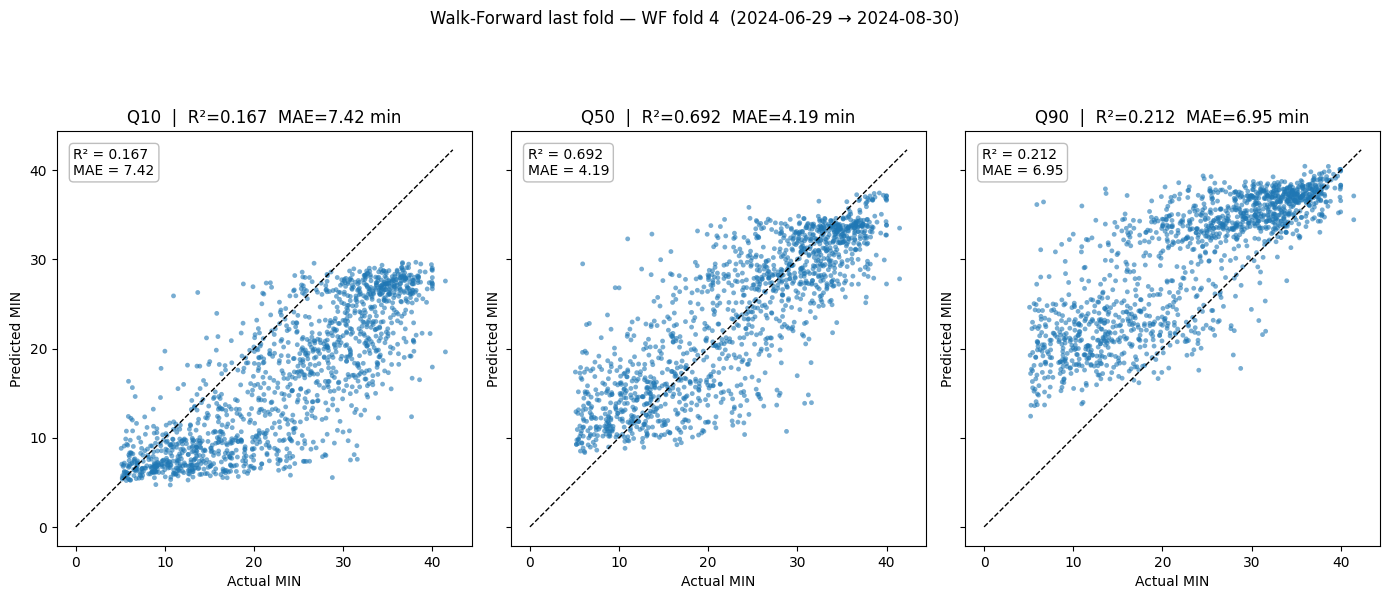

Per-quantile fit on last validation fold:
  Q10: R²=+0.167  MAE=7.424 min
  Q50: R²=+0.692  MAE=4.194 min
  Q90: R²=+0.212  MAE=6.948 min

Coverage per quantile (should match quantile value):
  Q10: 11.0%  (target 10%, delta +1.0%)  ✓
  Q50: 49.5%  (target 50%, delta -0.5%)  ✓
  Q90: 89.6%  (target 90%, delta -0.4%)  ✓

80% interval width (Q10→Q90):
  mean   : 13.39 min
  median : 13.32 min
  std    : 2.69 min


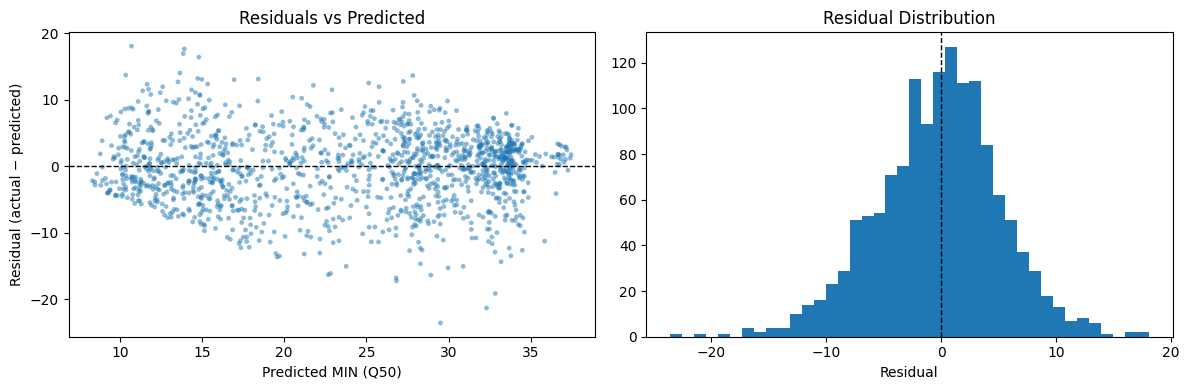


Residual summary:
  mean bias : -0.260 min  (close to 0 = unbiased)
  std       : 5.389 min

Residuals by role:
  Starters   | n=  829 | bias=-0.273 | std=5.204
  Bench      | n=  576 | bias=-0.242 | std=5.645

Residuals by minutes tier:
  <10 min    | n=  158 | bias=-5.969 | std=3.836
  10-20 min  | n=  368 | bias=-1.973 | std=5.099
  20-30 min  | n=  416 | bias=-0.072 | std=5.559
  30+ min    | n=  463 | bias=+2.880 | std=3.369


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.2f} min")
print(f"  median : {np.median(interval_width):.2f} min")
print(f"  std    : {interval_width.std():.2f} min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

# ── residuals stratified by role and minutes tier ─────────────────────────────
# uses starting_last set in the walk-forward loop
# ── re-derive starting using X_val_last.index (guaranteed same length as residuals) ──
starting_last = ppm_df.loc[X_val_last.index, "STARTING"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")

print("\nResiduals by minutes tier:")
for tier, fn in MIN_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")


── q_0.10 ──


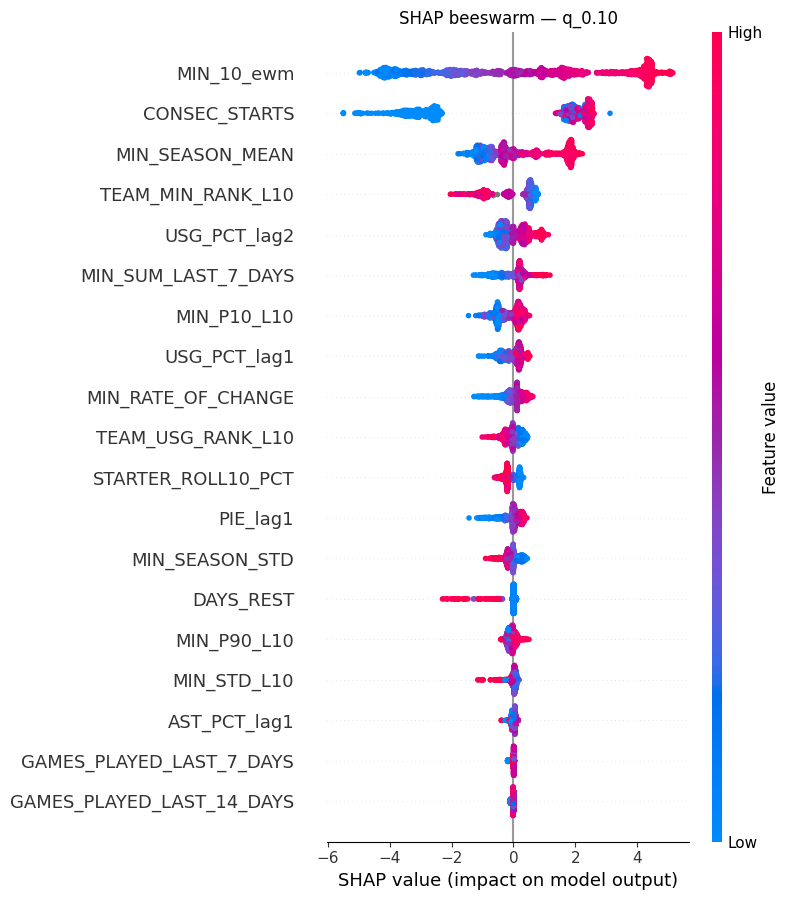


── q_0.50 ──


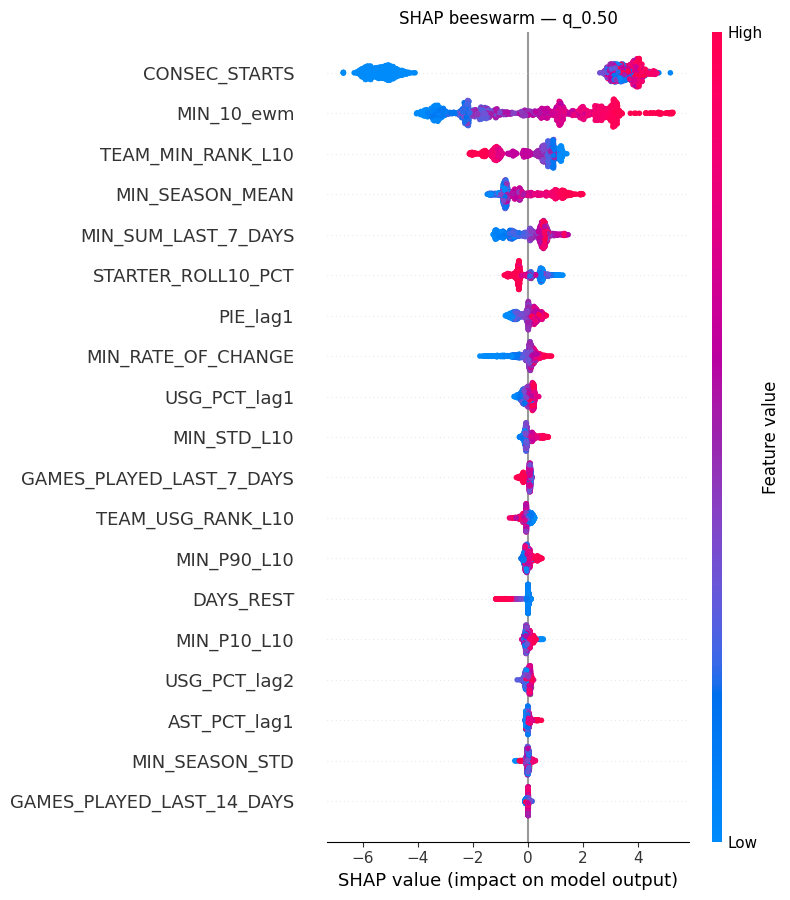


── q_0.90 ──


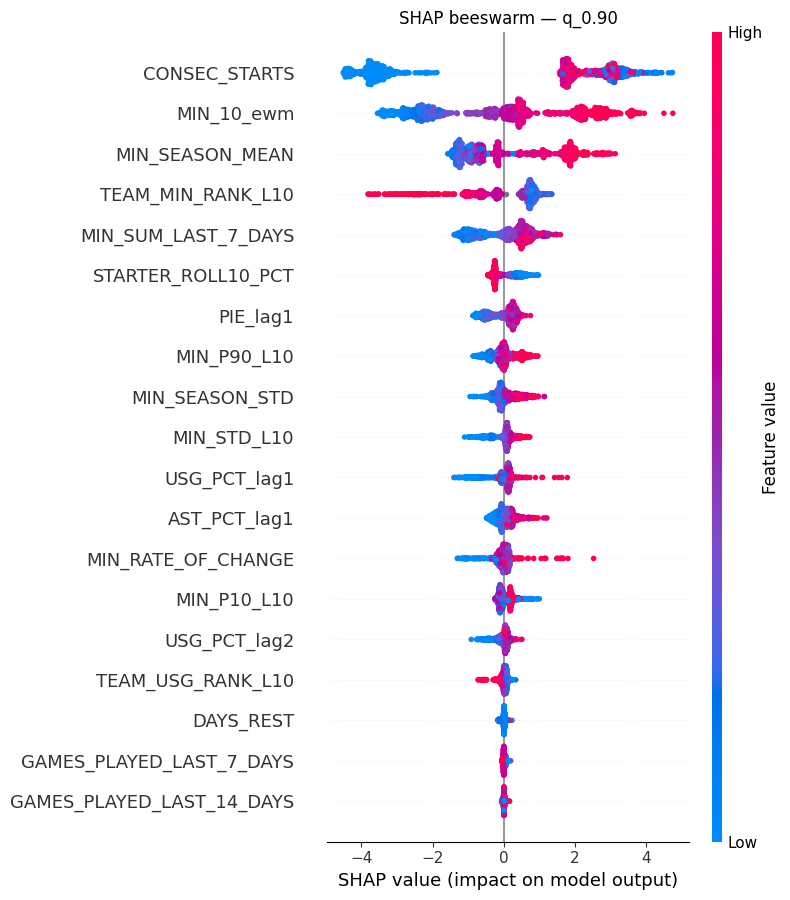

In [18]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

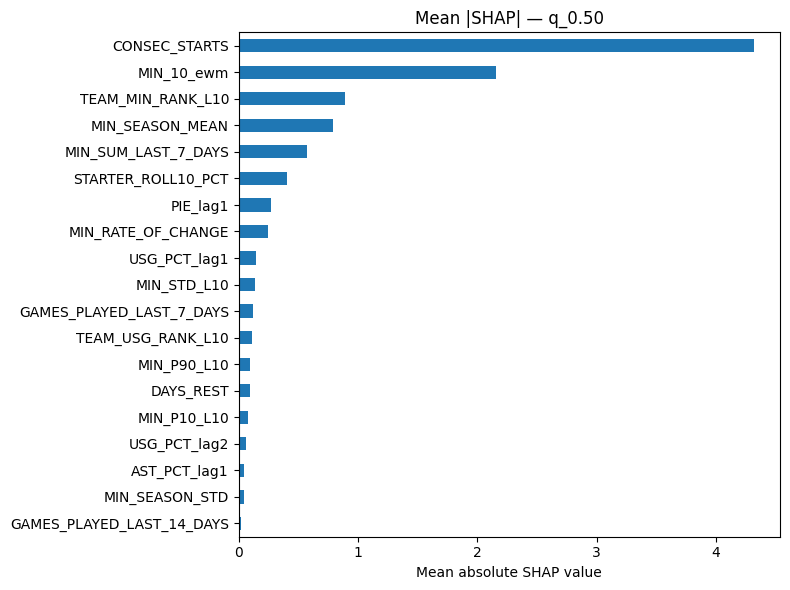

In [19]:
model = models_last["q_0.50"]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [20]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,   # ← no flip
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"]        = pi_df["std"].round(5)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                      feature  importance      std  p_value  significant
1               CONSEC_STARTS     1.02799  0.04438   0.0000         True
2                  MIN_10_ewm     0.62647  0.03073   0.0000         True
3           TEAM_MIN_RANK_L10     0.15249  0.01230   0.0000         True
4             MIN_SEASON_MEAN     0.13358  0.01139   0.0000         True
5         MIN_SUM_LAST_7_DAYS     0.07286  0.01011   0.0000         True
6          STARTER_ROLL10_PCT     0.02982  0.00874   0.0000         True
7           TEAM_USG_RANK_L10     0.02087  0.00353   0.0000         True
8                    PIE_lag1     0.01182  0.00395   0.0000         True
9                USG_PCT_lag1     0.00946  0.00229   0.0000         True
10         MIN_RATE_OF_CHANGE     0.00909  0.00509   0.6913        False
11               USG_PCT_lag2     0.00721  0.00142   0.0000         True
12                MIN_P90_L10     0.00530  

In [21]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))

baseline_rmse = rmse_median_ablation(MIN_FEATURES)
print(f"Baseline RMSE (all features): {baseline_rmse:.4f}")

rows = []
for feat in MIN_FEATURES:
    cols         = [c for c in MIN_FEATURES if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 4), "delta_rmse": round(delta, 4)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())

Baseline RMSE (all features): 5.3957
                      feature  ablated_rmse  delta_rmse
1               CONSEC_STARTS        5.9130      0.5173
2           TEAM_MIN_RANK_L10        5.4491      0.0534
3         MIN_SUM_LAST_7_DAYS        5.4420      0.0464
4          STARTER_ROLL10_PCT        5.4322      0.0366
5                AST_PCT_lag1        5.4227      0.0271
6   GAMES_PLAYED_LAST_14_DAYS        5.4166      0.0209
7                  MIN_10_ewm        5.4116      0.0159
8             MIN_SEASON_MEAN        5.4098      0.0141
9                USG_PCT_lag2        5.4093      0.0136
10   GAMES_PLAYED_LAST_7_DAYS        5.4082      0.0126
11                MIN_P10_L10        5.4068      0.0112
12          TEAM_USG_RANK_L10        5.4059      0.0102
13             MIN_SEASON_STD        5.4032      0.0076
14                MIN_P90_L10        5.4016      0.0060
15               USG_PCT_lag1        5.4008      0.0052
16                MIN_STD_L10        5.3973      0.0017
17         

In [22]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model    = models_last["q_0.50"]
X_tr_last = X[last_fold["train_mask"]]   # only needed if you want train SHAP — not used below

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":        X_val_last.columns,
    "mean_abs_shap":  _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,              # ← was X_tr.columns
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())

                      feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1               CONSEC_STARTS       4.320258          1          1          1.02799              0.04438  3.781083e-41          0.5173   1.000000   1.000000   1.000000   True
2                  MIN_10_ewm       2.152615          2          2          0.62647              0.03073  1.515911e-39          0.0159   0.498261   0.609413   0.553837   True
3           TEAM_MIN_RANK_L10       0.893854          3          3          0.15249              0.01230  2.648366e-33          0.0534   0.206898   0.148338   0.177618   True
4             MIN_SEASON_MEAN       0.789035          4          4          0.13358              0.01139  1.308364e-32          0.0141   0.182636   0.129943   0.156289   True
5         MIN_SUM_LAST_7_DAYS       0.570591          5          5          0.07286              0.01011  1.487837e-26       

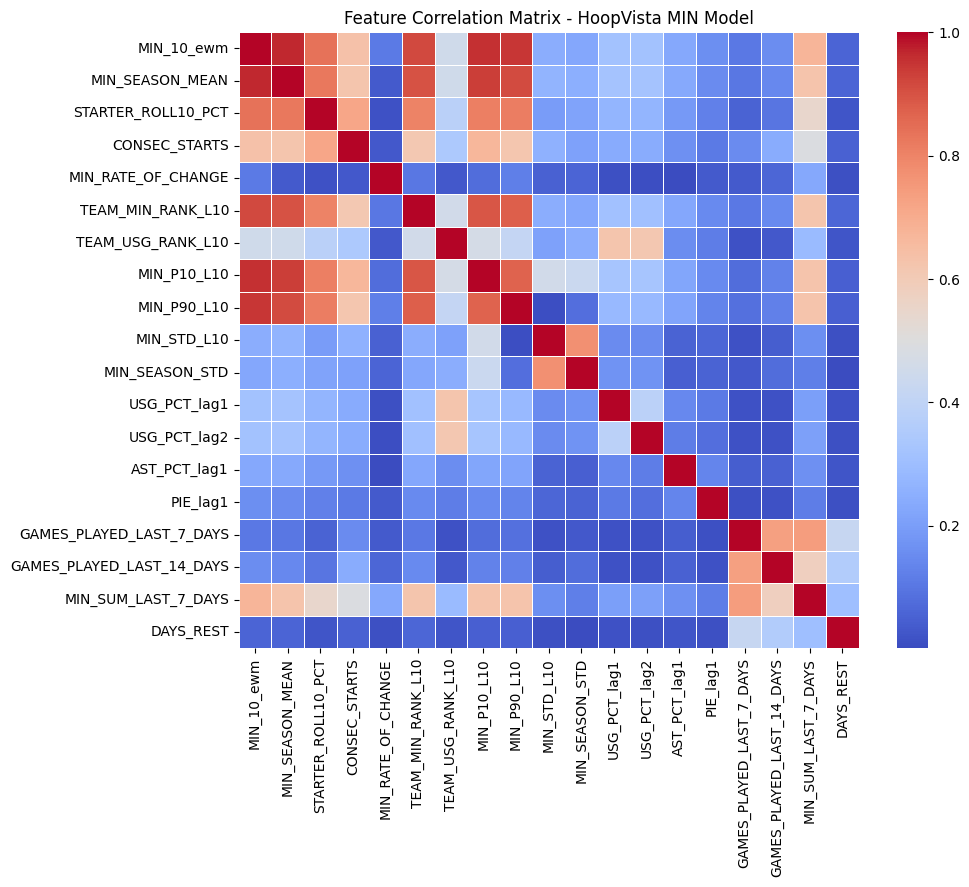

--- High Correlation Report (Threshold > 0.95) ---
MIN_SEASON_MEAN <-> MIN_10_ewm: 0.9657
MIN_P10_L10 <-> MIN_10_ewm: 0.9561


['MIN_SEASON_MEAN', 'MIN_P10_L10']

In [23]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [24]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S25
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S25 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S25 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S22–S24: 90% rows for fit, last 10% for early-stopping only; predict S25 (never in eval_set).")

X_train_full = ppm_df[MIN_FEATURES]
y_train_full = ppm_df["MIN"]
X_ho         = ppm_holdout[MIN_FEATURES]
y_ho         = ppm_holdout["MIN"]
starting_ho  = ppm_holdout["STARTING"].values

# Early stopping on last 10% of training only — S25 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S25 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE — gap indicates how optimistic
# the WF estimate was
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S22–S25)  : {wf_mae_mean:.3f} min")
print(f"  Holdout MAE      (S25)            : {ho_mae:.3f} min")
print(f"  Gap                               : {gap:+.3f} min  {'⚠ investigate' if abs(gap) > 0.5 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred    = preds_ho[q_key]
    actual  = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta   = actual_coverage - target
    flag    = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.2f} min  |  median: {np.median(interval_width):.2f} min  |  std: {interval_width.std():.2f} min")


── S25 Blind Holdout Evaluation ─────────────────────────────────────
  S22–S24: 90% rows for fit, last 10% for early-stopping only; predict S25 (never in eval_set).

S25 Blind Holdout
  Overall  | n= 5358 | MAE: 4.338 | R²: 0.619 | 80% Coverage: 78.7%
  Starters   | n= 3090 | MAE: 4.295 | Coverage: 79.9%
  Bench      | n= 2268 | MAE: 4.396 | Coverage: 77.2%
  <10 min    | n=  513 | MAE: 5.660 | Coverage: 49.5%
  10-20 min  | n= 1521 | MAE: 4.328 | Coverage: 85.3%
  20-30 min  | n= 1918 | MAE: 4.297 | Coverage: 82.6%
  30+ min    | n= 1406 | MAE: 3.922 | Coverage: 77.0%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S22–S25)  : 4.199 min
  Holdout MAE      (S25)            : 4.338 min
  Gap                               : +0.139 min  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 11.3%  target: 10%  delta: +1.3%  ✓
  q_0.50 | actual coverage: 50.4%  target: 50%  delta: +0.4%  ✓
  q_0.90 | actual coverage

In [25]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/
# Assumes notebook lives somewhere inside the repo (e.g. notebooks/ or root).

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   MIN_FEATURES,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       ppm_df["GAME_DATE"].max(),
    "val_end":         ppm_holdout["GAME_DATE"].max(),
}

save_path = save_dir / f"min_wnba_model_{ppm_holdout['GAME_DATE'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.3f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_minutes(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as MIN_FEATURES.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to c:\Users\alexg\OneDrive\src\models\saved_models\min_wnba_model_2025-10-10.joblib
Loaded model MAE (S26 holdout): 4.338
Trained on data up to        : 2024-10-20
Holdout through              : 2025-10-10
